[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfelipevasquez/Forecasting-electricity-production-Kaggle/blob/main/02_ModelComparision.ipynb)

# **Model Comparison & Selection**
This notebook evaluates various machine learning algorithms using cross-validation, with the Mean Absolute Error (MAE) as the primary performance metric. The top three performing models will be selected for a rigorous, in-depth analysis focusing on hyperparameter tuning and feature importance evaluation

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import  mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/jfelipevasquez/Forecasting-electricity-production-Kaggle/refs/heads/main/dataset/train.csv")
df.head()

,ID,start,kw,capacity_clipped,time_hourly,S_d,airmass,altitude,azimuth,irradiation,...,rad_lw_mean,precip_total_mean,cloud_total_mean,temp_total_mean,cloud_high_mean,rad_global_mean,cloud_low_mean,radNetS_lw_mean,cloud_mid_mean,radNetS_sw_mean
0,0,2019-01-02 01:00:00,0.0,468.0,2019-01-02 01:00:00.000000,0.0,-1.153310,-60.119844,39.300368,0.0,...,28559320.0,NaN,87.436623,2.016479,0.735016,3692351.75,0.517294,-4335172.0,0.510855,2910957.0
1,1,2019-01-02 01:15:00,0.0,468.0,2019-01-02 01:00:00.000000,0.0,-1.173570,-58.440884,45.209051,0.0,...,28559320.0,NaN,87.436623,2.016479,0.735016,3692351.75,0.517294,-4335172.0,0.510855,2910957.0
2,2,2019-01-02 01:45:00,0.0,468.0,2019-01-02 01:00:00.000000,0.0,-1.226941,-54.590829,55.621305,0.0,...,28559320.0,NaN,87.436623,2.016479,0.735016,3692351.75,0.517294,-4335172.0,0.510855,2910957.0
3,3,2019-01-02 02:45:00,0.0,468.0,2019-01-02 02:00:00.000000,0.0,-1.398963,-45.628041,72.112254,0.0,...,29545328.0,NaN,59.624264,2.035498,0.012997,3692351.75,0.329642,-4500247.5,0.370873,2910957.0
4,4,2019-01-02 03:00:00,0.0,468.0,2019-01-02 03:00:00.000000,0.0,-1.459987,-43.230706,75.591904,0.0,...,30531976.0,NaN,63.706104,2.246095,0.000000,3692351.75,0.238952,-4664002.0,0.493319,2910957.0


## Data Preprocessing
Based on the exploratory variable analysis carried out in a previous notebook, it was decided to adopt the strategy of building a model using only those variables that do not contain `NaN` data, which are the variables that have the greatest relevance or influence on electricity generation or `kw` .

In [3]:
# Remove columns that will not be useful
df_1 = df.dropna(axis=1).copy()
df_1.drop(columns=["ID", "day", "sunrise", "sunset"], inplace=True)

# Extract date, day of year, month, and hour variables
df_1["date"] = pd.to_datetime(df_1["start"])
df_1["month"] = df_1["date"].dt.month
df_1["day_of_year"] = df_1["date"].dt.dayofyear
df_1["hour"] = df_1["date"].dt.hour
df_1.drop(columns=["start", "time_hourly", "capacity_clipped"], inplace=True)


#  CREATE CYCLIC VARIABLES sin and cos ---------------
hour_period = 24
month_period = 12
day_of_year_period = 365

df_1["hour_sin"] = np.sin(2 * np.pi * df_1["hour"] / hour_period)
df_1["hour_cos"] = np.cos(2 * np.pi * df_1["hour"] / hour_period)

df_1["month_sin"] = np.sin(2 * np.pi * df_1["month"] / month_period)
df_1["month_cos"] = np.cos(2 * np.pi * df_1["month"] / month_period)

df_1["day_of_year_sin"] = np.sin(2 * np.pi * df_1["day_of_year"] / day_of_year_period)
df_1["day_of_year_cos"] = np.cos( 2 * np.pi * df_1["day_of_year"] / day_of_year_period)
df_1.head(10)

,kw,S_d,airmass,altitude,azimuth,irradiation,fold_cos,panel_cos,date,month,day_of_year,hour,hour_sin,hour_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,0.0,0.0,-1.153310,-60.119844,39.300368,0.0,-0.0,-0.0,2019-01-02 01:00:00,1,2,1,0.258819,0.965926,0.5,0.866025,0.034422,0.999407
1,0.0,0.0,-1.173570,-58.440884,45.209051,0.0,-0.0,-0.0,2019-01-02 01:15:00,1,2,1,0.258819,0.965926,0.5,0.866025,0.034422,0.999407
2,0.0,0.0,-1.226941,-54.590829,55.621305,0.0,-0.0,-0.0,2019-01-02 01:45:00,1,2,1,0.258819,0.965926,0.5,0.866025,0.034422,0.999407
3,0.0,0.0,-1.398963,-45.628041,72.112254,0.0,-0.0,-0.0,2019-01-02 02:45:00,1,2,2,0.500000,0.866025,0.5,0.866025,0.034422,0.999407
4,0.0,0.0,-1.459987,-43.230706,75.591904,0.0,-0.0,-0.0,2019-01-02 03:00:00,1,2,3,0.707107,0.707107,0.5,0.866025,0.034422,0.999407
5,0.0,0.0,-1.530514,-40.796573,78.887677,0.0,-0.0,-0.0,2019-01-02 03:15:00,1,2,3,0.707107,0.707107,0.5,0.866025,0.034422,0.999407
6,0.0,0.0,-1.707234,-35.855487,85.040351,0.0,-0.0,-0.0,2019-01-02 03:45:00,1,2,3,0.707107,0.707107,0.5,0.866025,0.034422,0.999407
7,0.0,0.0,-1.818306,-33.364431,87.944856,0.0,-0.0,-0.0,2019-01-02 04:00:00,1,2,4,0.866025,0.500000,0.5,0.866025,0.034422,0.999407
8,0.0,0.0,-1.949033,-30.868862,90.761663,0.0,-0.0,-0.0,2019-01-02 04:15:00,1,2,4,0.866025,0.500000,0.5,0.866025,0.034422,0.999407
9,0.0,0.0,-2.104208,-28.374865,93.507916,0.0,-0.0,-0.0,2019-01-02 04:30:00,1,2,4,0.866025,0.500000,0.5,0.866025,0.034422,0.999407


### Correlations
Examine the linear correlations of all the variables created with the target variable kw

In [4]:
# --- CORRELATIONS ---
df_1.corr(numeric_only=True)['kw'].sort_values(ascending=False)


,kw
kw,1.000000
irradiation,0.851681
fold_cos,0.836732
panel_cos,0.822872
S_d,0.787567
altitude,0.732397
airmass,0.097989
day_of_year_sin,0.039661
hour_sin,0.039139
hour,0.024805


### Data Preparation
Use shuffle to randomize data order, preventing models from learning artificial patterns based on how the dataset was collected or sorted

In [5]:
from sklearn.utils import shuffle

# 1. Separar X e y
y = df_1['kw']

X = df_1.drop(columns=['kw', 'month', 'hour', 'day_of_year', 'date'])

# 2. Barajar manteniendo la relación entre X e y
X, y = shuffle(X, y, random_state=42)

# Opcional: Reiniciar índices para que empiecen de 0
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(X,y, test_size=0.2)

X

,S_d,airmass,altitude,azimuth,irradiation,fold_cos,panel_cos,hour_sin,hour_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos
0,0.000000,-3.700099,-15.679920,335.932055,0.000000,-0.000000,-0.000000,-0.258819,0.965926,-5.000000e-01,-8.660254e-01,-0.111659,-0.993747
1,0.000000,-1.607846,-38.458691,54.265011,0.000000,-0.000000,-0.000000,0.500000,0.866025,8.660254e-01,5.000000e-01,0.840618,0.541628
2,0.585909,3.675309,15.788433,84.603579,0.122073,0.272086,0.208348,0.965926,-0.258819,5.000000e-01,-8.660254e-01,0.845249,-0.534373
3,0.804844,1.805641,33.629475,178.764139,0.687125,0.553820,0.853737,0.258819,-0.965926,1.000000e+00,6.123234e-17,0.867456,0.497513
4,0.802053,1.823610,33.254780,149.746179,0.643457,0.548363,0.802262,0.500000,-0.866025,-8.660254e-01,5.000000e-01,-0.999769,0.021516
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23460,0.916472,1.178229,58.073993,224.302462,0.851545,0.848732,0.929156,-0.500000,-0.866025,-5.000000e-01,-8.660254e-01,-0.128748,-0.991677
23461,0.000000,-3.753493,-15.451257,105.736963,0.000000,-0.000000,-0.000000,0.965926,0.258819,-2.449294e-16,1.000000e+00,-0.493776,0.869589
23462,0.000000,-2.123400,-28.095509,312.848607,0.000000,-0.000000,-0.000000,-0.707107,0.707107,1.000000e+00,6.123234e-17,0.999250,0.038722
23463,0.000000,-1.968193,-30.536038,88.176464,0.000000,-0.000000,-0.000000,0.866025,0.500000,5.000000e-01,8.660254e-01,0.271958,0.962309


## Linear Regression





In [6]:
from sklearn.linear_model import LinearRegression

Linear_Regression = LinearRegression()
Linear_Regression.fit(x_train, y_train)

y_pred = Linear_Regression.predict(x_test)

mae_LR = mean_absolute_error(y_test, y_pred)
r2_LR = r2_score(y_test, y_pred)

print(f"Linear Regression MAE: {mae_LR:.2f}")
print(f"Linear Regression R2: {r2_LR:.3f}")

Linear Regression MAE: 37.60
Linear Regression R2: 0.735


In [7]:
# Cross Validation
scores = cross_validate(
    Linear_Regression,
    x_train,
    y_train,
    scoring = {
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    cv=5
)

LR_mae_scores = (-scores["test_mae"]).round(3)
LR_mae_scores
LR_r2_scores = (scores["test_r2"])
MAE_mean_LR= np.mean(LR_mae_scores.T)
R2_mean_LR= np.mean(LR_r2_scores.T)

print('Mean of MAE: ', MAE_mean_LR)
print('Mean of R2: ', R2_mean_LR)

Mean of MAE:  38.0714
Mean of R2:  0.7304191952109671


### Ridge

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(x_train, y_train)

y_pred_ridge = ridge_model.predict(x_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge MAE:", mae_ridge)

Ridge MAE: 37.57123385683699


In [9]:
scores = cross_val_score(ridge_model, x_train, y_train, scoring="neg_mean_absolute_error", cv=5)

Ridge_mae_scores = (-scores).round(3)
Ridge_mae_scores.T
MAE_mean_Ridge = np.mean(Ridge_mae_scores.T)
print('Mean of MAE: ', MAE_mean_Ridge)

Mean of MAE:  38.031800000000004


### Lasso

In [10]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1))
])

lasso_model.fit(x_train, y_train)

y_pred_lasso = lasso_model.predict(x_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso  MAE:", mae_lasso)

Lasso  MAE: 36.88118458959114


In [11]:
scores = cross_val_score(lasso_model, x_train, y_train, scoring="neg_mean_absolute_error", cv=5)

Lasso_mae_scores = (-scores).round(3)
Lasso_mae_scores.T
MAE_mean_Lasso = np.mean(Lasso_mae_scores.T)
print('Mean of MAE: ', MAE_mean_Lasso)

Mean of MAE:  37.3754


## Decision Tree

In [12]:
from sklearn.tree import DecisionTreeRegressor

Decision_Tree = DecisionTreeRegressor(
    max_depth=8,                         # Profundida máxima del arbol
    min_samples_split=10,                # Muestras mínimas para dividir nodo
    min_samples_leaf=5,                  # Muestras mínimas por hoja
    random_state=42                      # Semilla aleatoria
)

Decision_Tree.fit(x_train, y_train)

y_pred = Decision_Tree.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree MAE: {mae:.2f}")
print(f"Decision Tree R2: {r2:.3f}")

Decision Tree MAE: 28.13
Decision Tree R2: 0.795


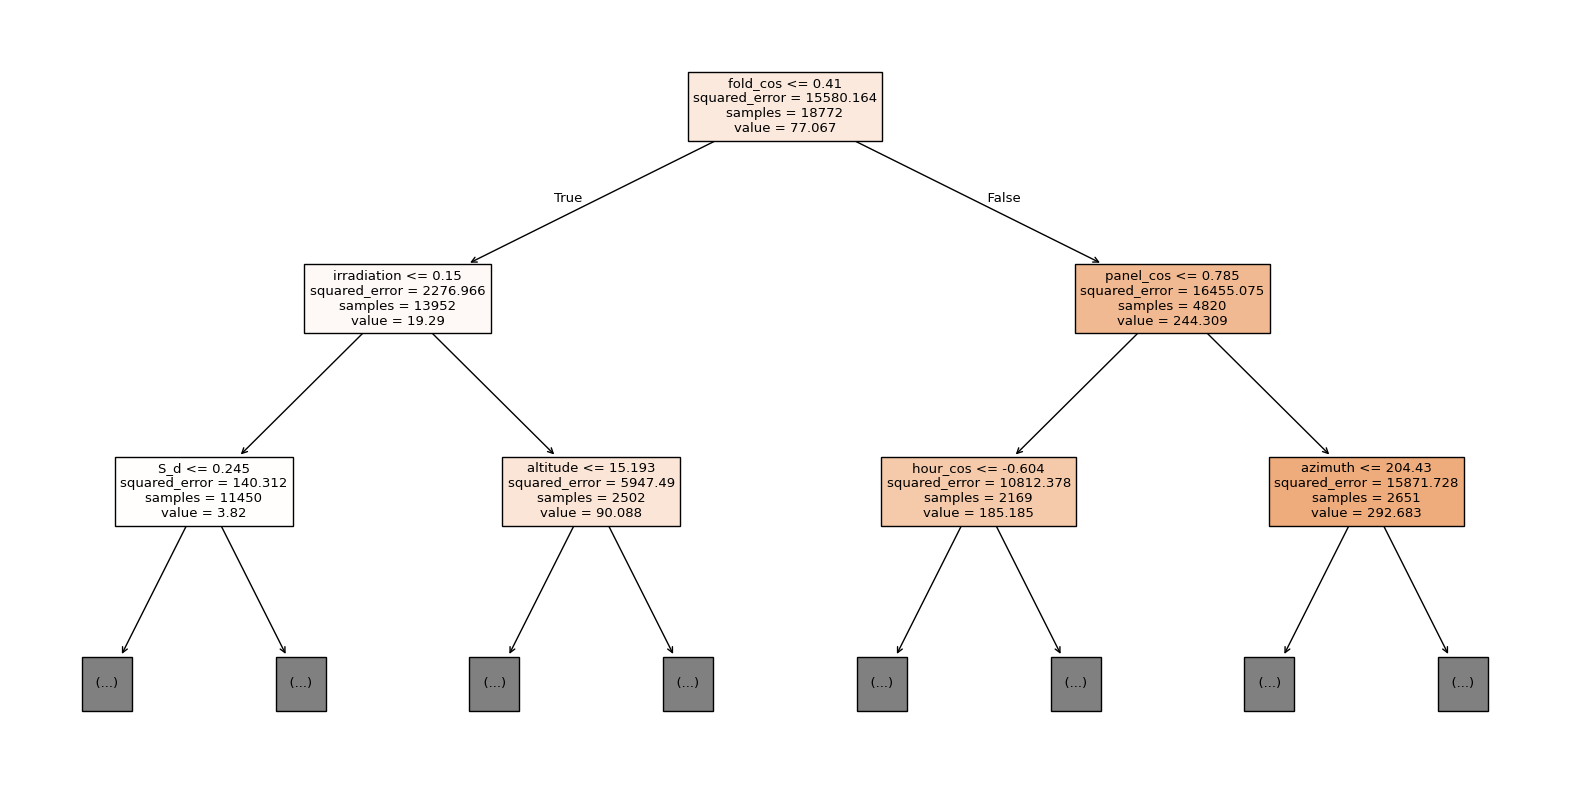

In [13]:
# Visualise the model. This allows you to understand how the model works

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(Decision_Tree, feature_names=x_train.columns, filled=True, max_depth=2)
plt.show()

In [14]:
# Cross Validation

scores = cross_val_score(Decision_Tree, x_train, y_train, scoring="neg_mean_absolute_error", cv=5)
DT_mae_scores = (-scores).round(3)
DT_mae_scores.T
MAE_mean_DT = np.mean(DT_mae_scores.T)
print('Mean of MAE: ', MAE_mean_DT)

Mean of MAE:  29.696000000000005


## Random Forest Rgressor

In [15]:
from sklearn.ensemble import RandomForestRegressor

Random_Forest = RandomForestRegressor()

Random_Forest = RandomForestRegressor(
    n_estimators=200,     # Número de arboles del bosque
    max_depth=None,       # Pofundidad del arbol
    min_samples_split=2,  # Muestras mínimas para dividir nodo
    min_samples_leaf=1,   # Muestras mínimas por hoja
    max_features='sqrt',  # Variables que usa cada árbol
    n_jobs=-1,            # Usa todas las CPU para entrenar más rapido
    random_state=42       # Semilla aleatoria
)

Random_Forest.fit(x_train, y_train)

y_pred = Random_Forest.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f" Random Forest MAE: {mae:.2f}")
print(f"Random Forest R2: {r2:.3f}")

 Random Forest MAE: 26.07
Random Forest R2: 0.816


In [16]:
# Cross Validation R
scores = cross_val_score(Random_Forest, x_train, y_train, scoring="neg_mean_absolute_error", cv=5)
RF_mae_scores = (-scores).round(3)
RF_mae_scores.T
MAE_mean_RF = np.mean(RF_mae_scores.T)
print('Mean of MAE: ', MAE_mean_RF)

Mean of MAE:  27.236


## XG Boost

In [17]:
from xgboost import XGBRegressor

# Inicializar el modelo y entrenarlo en una sola línea
XGBoost = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
XGBoost.fit(X, y)

y_pred = XGBoost.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R2: {r2:.3f}")

XGBoost MAE: 20.20
XGBoost R2: 0.904


In [18]:
# Cross Validation
scores = cross_val_score(XGBoost, x_train, y_train, scoring="neg_mean_absolute_error", cv=5)
XGB_mae_scores = (-scores).round(3)

MAE_mean_XGB = np.mean(XGB_mae_scores.T)
MAE_std_XGB = np.std(XGB_mae_scores.T)
print('Mean of MAE: ', MAE_mean_XGB)


Mean of MAE:  23.8396


## Light GBM Regressor

In [19]:
from lightgbm import LGBMRegressor

LightGBM = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)
LightGBM.fit(X, y)

y_pred = LightGBM.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Light GBM MAE: {mae:.2f}")
print(f"Light GBM R2: {r2:.3f}")

Light GBM MAE: 19.11
Light GBM R2: 0.910


In [20]:
# Cross Validation
scores = cross_val_score(LightGBM, x_train, y_train, scoring="neg_mean_absolute_error", cv=5, verbose=0)

LGB_mae_scores = (-scores).round(3)
LGB_mae_scores.T

MAE_mean_LGB = np.mean(LGB_mae_scores.T)
print('Mean of MAE: ', MAE_mean_LGB)

Mean of MAE:  22.5902


## CatBoost

In [21]:
!pip install catboost

In [22]:
from catboost import CatBoostRegressor

CatBoost = CatBoostRegressor(
    n_estimators=100,
    learning_rate=0.1,
    verbose=0,
    random_state=42)

CatBoost.fit(X, y)

y_pred = CatBoost.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"CatBoost MAE: {mae:.2f}")
print(f"CatBoost R2: {r2:.3f}")

CatBoost MAE: 26.88
CatBoost R2: 0.830


In [23]:
scores = cross_val_score(CatBoost, x_train, y_train, scoring="neg_mean_absolute_error", cv=5)

CatB_mae_scores = (-scores).round(3)
CatB_mae_scores.T

MAE_mean_CatB = np.mean(CatB_mae_scores.T)
print('Mean of MAE: ', MAE_mean_CatB)

Mean of MAE:  28.3856


## Summary of results

The following table lists, in ascending order, the average MAE obtained by evaluating different models using cross-validation




In [24]:
MAEs = {'Linear Regression': MAE_mean_LR,
        'Ridge': MAE_mean_Ridge,
        'Lasso': MAE_mean_Lasso,
        'Decision Tree':MAE_mean_DT,
        'Random Forest':MAE_mean_RF,
        'XGBoost':MAE_mean_XGB,
        'Light GBM':MAE_mean_LGB,
        'Cat Boost': MAE_mean_CatB}

pd.DataFrame(MAEs.items(), columns=['Model', 'MAE mean']).sort_values(by='MAE mean', ascending=True)



,Model,MAE mean
6,Light GBM,22.5902
5,XGBoost,23.8396
4,Random Forest,27.2360
7,Cat Boost,28.3856
3,Decision Tree,29.6960
2,Lasso,37.3754
1,Ridge,38.0318
0,Linear Regression,38.0714
